# 1. Calculating Entropy

In [1]:
import numpy as np

def entropy(data):
    """ Calculates Shannon Entropy (log base 2) based on class counts. """

    # 1. Get counts and size
    _, counts = np.unique(data, return_counts=True)
    n = len(data)

    # 2. Calculate probabilities
    probabilities = counts / n

    # 3. Apply formula H(X) = - sum(P(xi) * log2(P(xi)))
    # Note: log2(0) is undefined, so handling is necessary if classes are pure (p=1)

    entropy_value = -np.sum(probabilities * np.log2(probabilities))
    return entropy_value


In [2]:
# Example D1: Fair Coin (2 H, 2 T) -> Expected result: 1.0 (p. 101)
data_d1 = ['H', 'T', 'H', 'T']
print(f"Entropy(D1): {entropy(data_d1)}")

# Example D2: Unfair Coin (4 H, 0 T) -> Expected result: 0.0 (p. 101)
data_d2 = ['H', 'H', 'H', 'H']
print(f"Entropy(D2): {entropy(data_d2)}")

Entropy(D1): 1.0
Entropy(D2): -0.0


# 2. Calculating Information Gain

In [3]:
def info_a(subsets):
    """ Calculates Info_A(D) - Expected Entropy. """
    total_size = sum(len(s) for s in subsets)
    expected_entropy = 0

    # Sum of (weight * Entropy(subset))
    for subset in subsets:
        weight = len(subset) / total_size
        expected_entropy += weight * entropy(subset)

    return expected_entropy

def information_gain(parent_data, subsets):
    """ Calculates Gain(A) = Info(D) - Info_A(D). """
    info_d = entropy(parent_data)
    info_a_d = info_a(subsets)
    return info_d - info_a_d

In [4]:
# --- Example using Gender Split ---
parent_data = ['P', 'P', 'N', 'U'] # P=Positive, N=Negative, U=Neutral
info_d_calc = entropy(parent_data) # Should be 1.5
print(f"info_d = {info_d_calc}")

# Split by Gender:
male_subset = ['P', 'P']       # Entropy = 0
female_subset = ['N', 'U']     # Entropy = 1

subsets = [male_subset, female_subset]

# Info_A_Gender = 0.5
info_a_gender_calc = info_a(subsets)
print(f"Info_A_Gender = {info_a_gender_calc}")

# Gain(Gender) = 1.0
gain_gender_calc = info_d_calc - info_a_gender_calc
print(f"Gain(Gender) = {gain_gender_calc}")

info_d = 1.5
Info_A_Gender = 0.5
Gain(Gender) = 1.0


# 3. Decision Trees

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



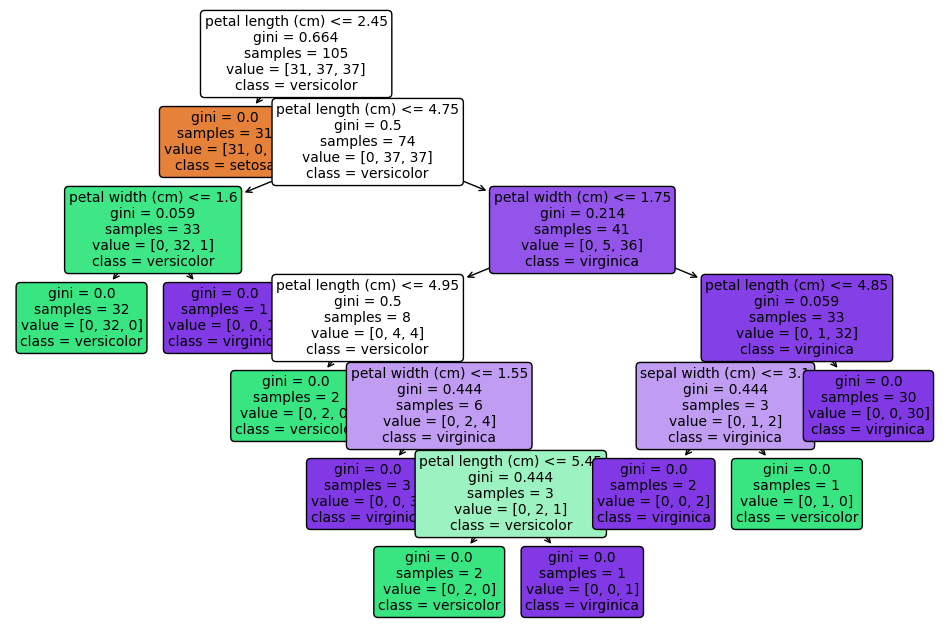

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data        # features (sepal length, sepal width, petal length, petal width)
y = iris.target      # target classes (setosa, versicolor, virginica)

# 2. Split the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Initialize and train a Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = clf.predict(X_test)

# 5. Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. (Optional) Visualize the decision tree
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.show()


In [ ]:
print(iris.feature_names, iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


# 4. Predict on new data

In [ ]:
import numpy as np
# Generate a random array of 2 rows and 4 columns in [0, 1)
new_data = np.random.rand(20, 4)
# Predict on new data
output = clf.predict(new_data)
# Print new data and output
print(new_data)
print(output)

[[0.45681123 0.52511593 0.531186   0.66352623]
 [0.23368875 0.86266805 0.78264798 0.76341974]
 [0.7307912  0.78353466 0.53317816 0.47523427]
 [0.68667873 0.52846924 0.96015797 0.66234721]
 [0.8242589  0.55448616 0.39242082 0.18649026]
 [0.38317659 0.57146105 0.68930349 0.30036344]
 [0.83127776 0.51063598 0.60324764 0.4508477 ]
 [0.28817969 0.96251727 0.02047887 0.14860999]
 [0.96148848 0.76115642 0.875658   0.34660796]
 [0.22667464 0.18220473 0.23403409 0.85658044]
 [0.16047044 0.76464165 0.93279983 0.47786367]
 [0.01119345 0.74181068 0.43639306 0.57826493]
 [0.35546945 0.13865646 0.90182211 0.39573866]
 [0.32235767 0.4468042  0.94595524 0.52469756]
 [0.3469234  0.72883486 0.63979803 0.23053078]
 [0.84574378 0.54165893 0.99517084 0.59761894]
 [0.52065593 0.13801216 0.76863276 0.48151685]
 [0.33971469 0.73710652 0.89847264 0.16321494]
 [0.51706022 0.56743183 0.92522435 0.10880295]
 [0.39357998 0.01855587 0.99536781 0.70282977]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
